# 📝 Week 2: Preprocessing Teks untuk NLP

Notebook ini mendemonstrasikan tahapan **preprocessing teks** bahasa Indonesia, mulai dari pembersihan noise hingga analisis frekuensi kata.

## Tujuan Pembelajaran:
1. Memahami pentingnya preprocessing dalam pipeline NLP
2. Menerapkan case folding, cleaning, dan normalisasi kata
3. Melakukan tokenisasi serta stopword removal pada teks
4. Membandingkan teks sebelum dan sesudah preprocessing

In [15]:
import re
import csv
from pathlib import Path
from collections import Counter

# Contoh teks mentah yang sering muncul pada data media sosial/review.
raw_texts = [
    "AKU bener2 sukaa aplikasi ini!!! loadingnya lama bgt :( cek https://contoh.id #kecewa" ,
    "Min, tolong dong akun sy gk bisa login dr kmrn @csapp 2x coba tetep gagal" ,
    "Pelayanan di rs nya okeee, tp antre 3 jammmm... capekkk :')"
]

for i, t in enumerate(raw_texts, start=1):
    print(f"{i}. {t}")

1. AKU bener2 sukaa aplikasi ini!!! loadingnya lama bgt :( cek https://contoh.id #kecewa
2. Min, tolong dong akun sy gk bisa login dr kmrn @csapp 2x coba tetep gagal
3. Pelayanan di rs nya okeee, tp antre 3 jammmm... capekkk :')


## 1) Case Folding dan Normalisasi Spasi

Case folding mengubah seluruh huruf menjadi kecil agar konsisten. 
Normalisasi spasi menghapus spasi berlebih yang mengganggu proses tokenisasi.

In [16]:
def casefold_and_trim(text):
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

step1 = [casefold_and_trim(t) for t in raw_texts]

for before, after in zip(raw_texts, step1):
    print("SEBELUM:", before)
    print("SESUDAH:", after)
    print("-" * 80)

SEBELUM: AKU bener2 sukaa aplikasi ini!!! loadingnya lama bgt :( cek https://contoh.id #kecewa
SESUDAH: aku bener2 sukaa aplikasi ini!!! loadingnya lama bgt :( cek https://contoh.id #kecewa
--------------------------------------------------------------------------------
SEBELUM: Min, tolong dong akun sy gk bisa login dr kmrn @csapp 2x coba tetep gagal
SESUDAH: min, tolong dong akun sy gk bisa login dr kmrn @csapp 2x coba tetep gagal
--------------------------------------------------------------------------------
SEBELUM: Pelayanan di rs nya okeee, tp antre 3 jammmm... capekkk :')
SESUDAH: pelayanan di rs nya okeee, tp antre 3 jammmm... capekkk :')
--------------------------------------------------------------------------------


## 2) Hapus Noise: URL, Mention, Hashtag, Angka, Tanda Baca

Noise adalah bagian teks yang biasanya tidak membawa makna utama sentimen/topik.

In [17]:
def remove_noise(text):
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

step2 = [remove_noise(t) for t in step1]

for before, after in zip(step1, step2):
    print("SEBELUM:", before)
    print("SESUDAH:", after)
    print("-" * 80)

SEBELUM: aku bener2 sukaa aplikasi ini!!! loadingnya lama bgt :( cek https://contoh.id #kecewa
SESUDAH: aku bener sukaa aplikasi ini loadingnya lama bgt cek kecewa
--------------------------------------------------------------------------------
SEBELUM: min, tolong dong akun sy gk bisa login dr kmrn @csapp 2x coba tetep gagal
SESUDAH: min tolong dong akun sy gk bisa login dr kmrn x coba tetep gagal
--------------------------------------------------------------------------------
SEBELUM: pelayanan di rs nya okeee, tp antre 3 jammmm... capekkk :')
SESUDAH: pelayanan di rs nya okeee tp antre jammmm capekkk
--------------------------------------------------------------------------------


## 3) Normalisasi Kata Alay/Slang

Kita memanfaatkan kamus alay jika tersedia di folder workspace.

Prioritas normalisasi:
- Kamus lokal custom
- Kamus dari file `kamus-alay/colloquial-indonesian-lexicon.csv` (jika ada)

In [18]:
custom_slang = {
    "bgt": "banget",
    "gk": "tidak",
    "sy": "saya",
    "dr": "dari",
    "kmrn": "kemarin",
    "tp": "tapi",
    "rs": "rumahsakit"
}

def load_kamus_alay():
    lexicon = {}
    csv_path = Path.cwd().parents[1] / "kamus-alay" / "colloquial-indonesian-lexicon.csv"
    if csv_path.exists():
        with open(csv_path, "r", encoding="utf-8") as f:
            reader = csv.reader(f)
            for row in reader:
                if len(row) >= 2:
                    lexicon[row[0].strip()] = row[1].strip()
    return lexicon

kamus_alay = load_kamus_alay()
normalization_dict = {**kamus_alay, **custom_slang}

def normalize_slang(text, mapping):
    tokens = text.split()
    tokens = [mapping.get(tok, tok) for tok in tokens]
    return " ".join(tokens)

step3 = [normalize_slang(t, normalization_dict) for t in step2]

print(f"Jumlah entri normalisasi: {len(normalization_dict)}")
for before, after in zip(step2, step3):
    print("SEBELUM:", before)
    print("SESUDAH:", after)
    print("-" * 80)

Jumlah entri normalisasi: 4332
SEBELUM: aku bener sukaa aplikasi ini loadingnya lama bgt cek kecewa
SESUDAH: aku benar suka aplikasi ini loadingnya lama banget cek kecewa
--------------------------------------------------------------------------------
SEBELUM: min tolong dong akun sy gk bisa login dr kmrn x coba tetep gagal
SESUDAH: min tolong dong akun saya tidak bisa login dari kemarin kali coba tetap gagal
--------------------------------------------------------------------------------
SEBELUM: pelayanan di rs nya okeee tp antre jammmm capekkk
SESUDAH: pelayanan di rumahsakit nya okeee tapi antre jammmm capekkk
--------------------------------------------------------------------------------


## 4) Tokenisasi dan Stopword Removal

Daftar stopword di bawah ini adalah contoh sederhana dan bisa Anda kembangkan.

In [19]:
stopwords_id = {
    "yang", "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan",
    "saya", "aku", "nya", "min", "dong", "tetep", "jam", "x"
}

def tokenize(text):
    return text.split()

def remove_stopwords(tokens, stopword_set):
    return [tok for tok in tokens if tok not in stopword_set and len(tok) > 1]

tokenized = [tokenize(t) for t in step3]
clean_tokens = [remove_stopwords(toks, stopwords_id) for toks in tokenized]

for i, (tok, cln) in enumerate(zip(tokenized, clean_tokens), start=1):
    print(f"Dokumen {i}")
    print("Token awal :", tok)
    print("Token bersih:", cln)
    print("-" * 80)

Dokumen 1
Token awal : ['aku', 'benar', 'suka', 'aplikasi', 'ini', 'loadingnya', 'lama', 'banget', 'cek', 'kecewa']
Token bersih: ['benar', 'suka', 'aplikasi', 'loadingnya', 'lama', 'banget', 'cek', 'kecewa']
--------------------------------------------------------------------------------
Dokumen 2
Token awal : ['min', 'tolong', 'dong', 'akun', 'saya', 'tidak', 'bisa', 'login', 'dari', 'kemarin', 'kali', 'coba', 'tetap', 'gagal']
Token bersih: ['tolong', 'akun', 'tidak', 'bisa', 'login', 'kemarin', 'kali', 'coba', 'tetap', 'gagal']
--------------------------------------------------------------------------------
Dokumen 3
Token awal : ['pelayanan', 'di', 'rumahsakit', 'nya', 'okeee', 'tapi', 'antre', 'jammmm', 'capekkk']
Token bersih: ['pelayanan', 'rumahsakit', 'okeee', 'tapi', 'antre', 'jammmm', 'capekkk']
--------------------------------------------------------------------------------


## 5) Frequent Words dan Pipeline Akhir

Kita lihat kata paling sering setelah preprocessing untuk insight cepat.

Top 10 kata paling sering (setelah preprocessing):
- benar: 1
- suka: 1
- aplikasi: 1
- loadingnya: 1
- lama: 1
- banget: 1
- cek: 1
- kecewa: 1
- tolong: 1
- akun: 1


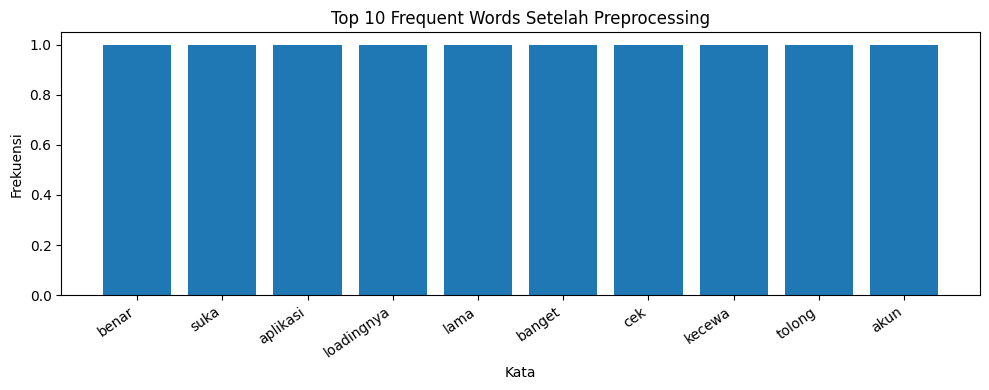


Contoh teks baru:
Makasih min, aplikasi nya bagus bgt tapi skrg login gk bisa sejak kmrn!!!
Hasil pipeline:
['terima', 'kasih', 'aplikasi', 'bagus', 'banget', 'tapi', 'sekarang', 'login', 'tidak', 'bisa', 'sejak', 'kemarin']


In [20]:
all_tokens = [tok for doc in clean_tokens for tok in doc]
freq = Counter(all_tokens)

print("Top 10 kata paling sering (setelah preprocessing):")
top10 = freq.most_common(10)
for word, count in top10:
    print(f"- {word}: {count}")

# Visualisasi sederhana agar insight cepat terlihat.
try:
    import matplotlib.pyplot as plt

    words = [w for w, _ in top10]
    counts = [c for _, c in top10]

    plt.figure(figsize=(10, 4))
    plt.bar(words, counts)
    plt.title("Top 10 Frequent Words Setelah Preprocessing")
    plt.xlabel("Kata")
    plt.ylabel("Frekuensi")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Visualisasi dilewati: {e}")

def preprocess_pipeline(text, mapping, stopword_set):
    text = casefold_and_trim(text)
    text = remove_noise(text)
    text = normalize_slang(text, mapping)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens, stopword_set)
    return tokens

new_text = "Makasih min, aplikasi nya bagus bgt tapi skrg login gk bisa sejak kmrn!!!"
print("\nContoh teks baru:")
print(new_text)
print("Hasil pipeline:")
print(preprocess_pipeline(new_text, normalization_dict, stopwords_id))

## Kesimpulan

Dengan preprocessing yang konsisten, kualitas fitur teks akan meningkat untuk tahap berikutnya seperti klasifikasi sentimen atau topic modeling.

Langkah lanjutan yang bisa ditambah:
- Stemming/Lemmatization (misalnya Sastrawi)
- N-gram feature extraction
- Visualisasi lanjutan (wordcloud/bar chart)